## 🎨 Image Segmentation with ClipSeg
### Este notebook demonstra como realizar a segmentação de imagens usando o modelo CIDAS/clipseg-rd64-refined do Hugging Face.

### O que é o ClipSeg?
O ClipSeg é um modelo de segmentação zero-shot que utiliza o backbone do CLIP. Ele permite segmentar objetos em uma imagem a partir de prompts de texto ou até mesmo de outras imagens de referência, sem precisar de treinamento específico para as classes que você deseja encontrar.

In [1]:
# Instalação das dependências (remova o comentário se necessário)
# %pip install -q transformers torch pillow matplotlib

# 🚀 Configuração e Carregamento do Modelo
## Vamos carregar o processador e o modelo pré-treinado

In [2]:
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from PIL import Image
import torch
import matplotlib.pyplot as plt
import os
import numpy as np

# Carregando o modelo e o processador
model_name = "CIDAS/clipseg-rd64-refined"
processor = CLIPSegProcessor.from_pretrained(model_name)
model = CLIPSegForImageSegmentation.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"Modelo carragado no: {device}")

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo carragado no: cpu


# 🖼️ Processamento das Imagens
#### Vamos mapear as imagens da pasta imagens com alguns prompts de exemplo para ver a segmentação funcionando.

In [3]:
image_dir = "imagens"
images_and_prompts = {
    "bird.jpg": ["bird", "branch"],
    "cats_dog.png": ["cat", "dog", "bed"],
    "kitchen.png": ["cabinet", "countertop", "sink", "stove", "refrigerator", "garlic", "spoon", "vase"],
    "pizza.png": ["pizza slice", "pepperoni", "cheese", "pizza", "table"]
}

def segment_image(image_path, prompts):
    # Carregar imagem
    image = Image.open(image_path).convert("RGB")
    
    # Processar inputs
    inputs = processor(text=prompts, images=[image] * len(prompts), padding="max_length", return_tensors="pt").to(device)
    
    # Predição
    with torch.no_grad():
        outputs = model(**inputs)
    
    # O output é um tensor de (len(prompts), 352, 352)
    preds = torch.sigmoid(outputs.logits)
    
    return image, preds

def plot_results(image, preds, prompts):
    n = len(prompts)
    fig, ax = plt.subplots(1, n + 1, figsize=((n + 1) * 4, 4))
    
    # Mostrar imagem original
    ax[0].imshow(image)
    ax[0].set_title("Original")
    ax[0].axis("off")
    
    # Mostrar máscaras para cada prompt
    for i, prompt in enumerate(prompts):
        mask = preds[i].cpu().numpy()
        ax[i+1].imshow(image)
        ax[i+1].imshow(mask, alpha=0.6, cmap='jet')
        ax[i+1].set_title(f"Prompt: {prompt}")
        ax[i+1].axis("off")
    
    plt.show()

## 🔍 Visualizando Resultados
#### Agora vamos percorrer nossa lista de imagens e prompts predefinidos.

Processando: bird.jpg...


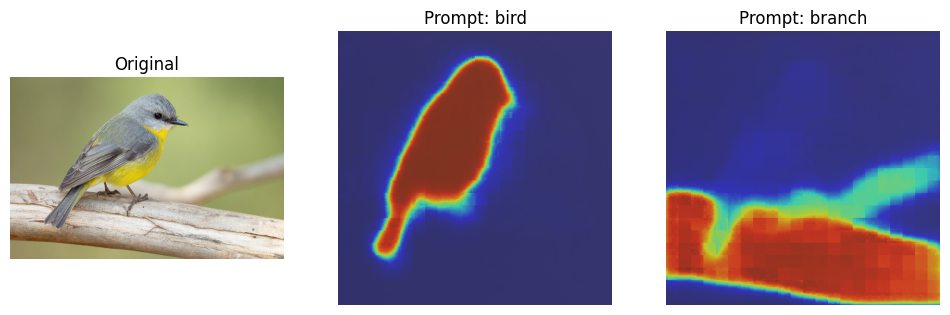

Processando: cats_dog.png...


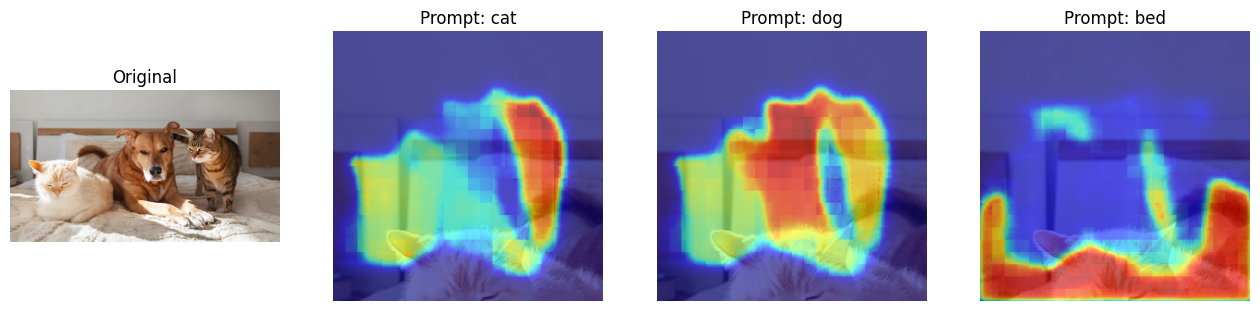

Processando: kitchen.png...


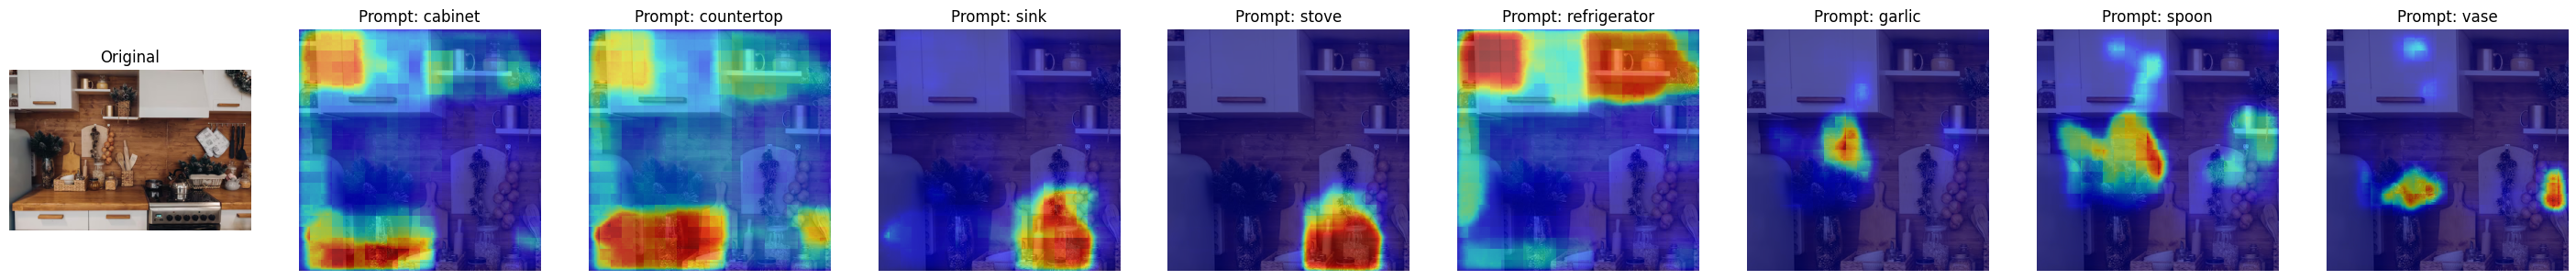

Processando: pizza.png...


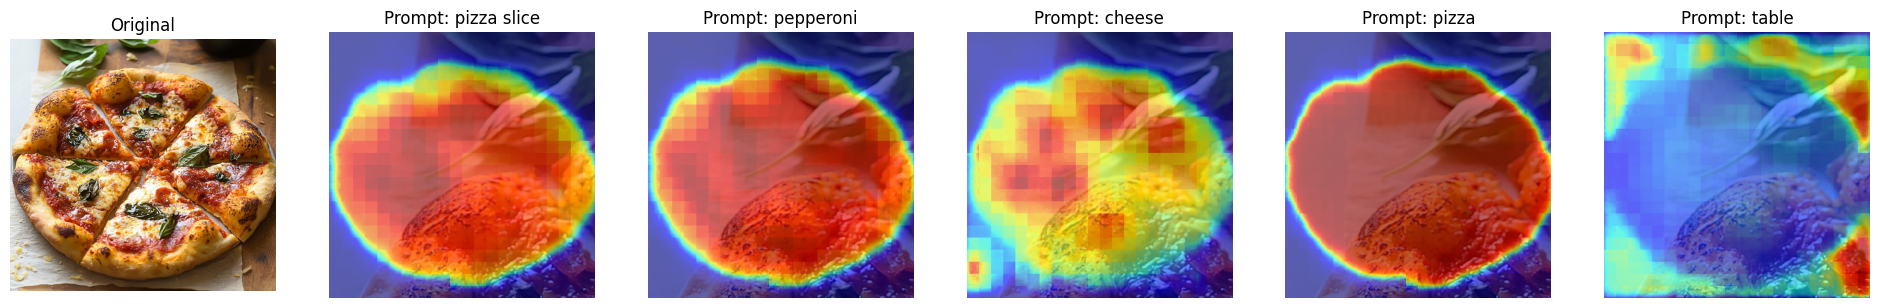

In [4]:
for img_name, prompts in images_and_prompts.items():
    path = os.path.join(image_dir, img_name)
    if os.path.exists(path):
        print(f"Processando: {img_name}...")
        img, prediction = segment_image(path, prompts)
        plot_results(img, prediction, prompts)
    else:
        print(f"Aviso: {img_name} não encontrada em {image_dir}.")

# 💡Como funciona?
#### O modelo ClipSeg usa o CLIP para alinhar as representações visuais e textuais. Ele recebe um prompt (ex: "pizza") e gera um mapa de ativação que destaca os pixels que mais se assemelham a esse conceito.

#### Escalabilidade: Diferente de modelos clássicos como Mask R-CNN que precisam de classes fixas, o ClipSeg pode segmentar qualquer coisa que o CLIP conheça.
#### Flexibilidade: Você pode usá-lo para encontrar objetos específicos em cenas complexas apenas variando o texto.